In [64]:
import pandas as pd


In [65]:
df = pd.read_csv("../data/ratings.csv")

In [66]:
df.head()

,UserID,MovieID,Rating,Date
0,1488844,1,3,2005-09-06
1,822109,1,5,2005-05-13
2,885013,1,4,2005-10-19
3,30878,1,4,2005-12-26
4,823519,1,3,2004-05-03


In [67]:
df.shape

(99971, 4)

In [68]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 99971 entries, 0 to 99970
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   UserID   99971 non-null  int64
 1   MovieID  99971 non-null  int64
 2   Rating   99971 non-null  int64
 3   Date     99971 non-null  str  
dtypes: int64(3), str(1)
memory usage: 4.0 MB


In [69]:
print("Total Ratings:", len(df))

print("Unique Users:", df['UserID'].nunique())

print("Unique Movies:", df['MovieID'].nunique())

print("Average Rating:", round(df['Rating'].mean(), 2))

Total Ratings: 99971
Unique Users: 81473
Unique Movies: 30
Average Rating: 3.53


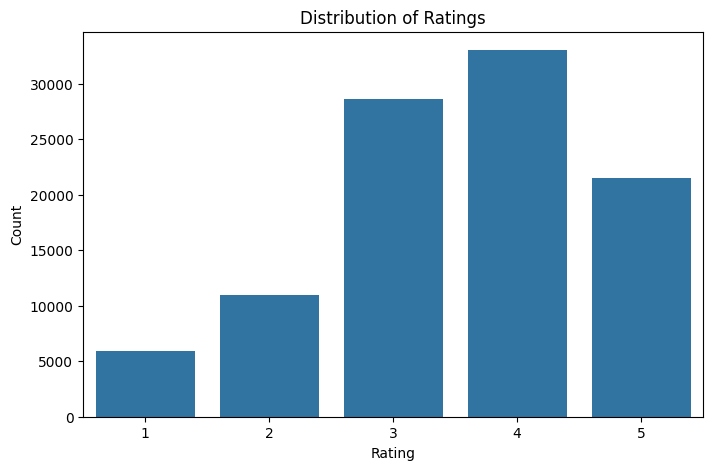

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.countplot(x='Rating', data=df)

plt.title("Distribution of Ratings")

plt.xlabel("Rating")

plt.ylabel("Count")

plt.show()

In [71]:
user_activity = df.groupby('UserID').size()

top_users = user_activity.sort_values(
    ascending=False
).head(10)

print(top_users)

UserID
305344     28
387418     28
2439493    27
2118461    25
1664010    25
1932594    16
1461435    16
1314869    14
2056022    14
1403217    14
dtype: int64


In [72]:
movie_popularity = df.groupby(
    'MovieID'
).size()

top_movies = movie_popularity.sort_values(
    ascending=False
).head(10)

print(top_movies)


MovieID
28    39752
8     14910
18    10722
30     7173
17     7108
26     5861
16     2699
3      2012
24     1333
25     1207
dtype: int64


In [73]:
users = df['UserID'].nunique()

movies = df['MovieID'].nunique()

ratings = len(df)

sparsity = 1 - (
    ratings / (users * movies)
)

print("Sparsity:", sparsity)

Sparsity: 0.9590985152545424


In [74]:
user_movie_matrix = df.pivot_table(
    index='UserID',
    columns='MovieID',
    values='Rating'
)

user_movie_matrix.head()

MovieID,1,2,3,4,5,6,7,8,9,10,...,21,22,23,24,25,26,27,28,29,30
UserID,,,,,,,,,,,,,,,,,,,,,
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,NaN,NaN
134,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0,NaN,NaN
201,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,NaN,NaN
261,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0
265,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,NaN,NaN


In [75]:
from surprise import Dataset
from surprise import Reader

In [76]:
reader = Reader(rating_scale=(1,5))

data = Dataset.load_from_df(
    df[['UserID','MovieID','Rating']],
    reader
)

In [77]:
from surprise.model_selection import train_test_split
trainset, testset = train_test_split(
    data,
    test_size=0.2,
    random_state=42
)

In [78]:
from surprise import KNNBasic

In [79]:
# User-Based Collaborative Filtering becomes computationally expensive for large numbers of users because it requires construction of a user-user similarity matrix.

In [80]:
from surprise import KNNBasic

sim_options = {
    'name': 'cosine',
    'user_based': False
}

item_model = KNNBasic(
    sim_options=sim_options
)

In [81]:
item_model.fit(trainset)

Computing the cosine similarity matrix...
Done computing similarity matrix.


In [82]:
predictions_item = item_model.test(testset)

In [83]:
from surprise import accuracy

rmse_item = accuracy.rmse(predictions_item)
print("Item-CF RMSE:", rmse_item)

RMSE: 1.1953
Item-CF RMSE: 1.1952981629623443


In [84]:
from surprise import SVD
svd_model = SVD()
svd_model.fit(trainset)

In [85]:
predictions = svd_model.test(testset)

In [86]:
from surprise import accuracy

rmse = accuracy.rmse(predictions)

RMSE: 1.0546


In [87]:
print(trainset.n_users ,
trainset.n_items)

67597 30


In [88]:
user_id = df['UserID'].iloc[0]

print("Selected User:", user_id)

Selected User: 1488844


In [89]:
rated_movies = df[df['UserID'] == user_id]['MovieID']

print("Number of movies rated:", len(rated_movies))
print(rated_movies.tolist())

Number of movies rated: 4
[1, 8, 17, 30]


In [90]:
all_movies = set(df['MovieID'].unique())

rated_movies = set(
    df[df['UserID'] == user_id]['MovieID']
)

unseen_movies = all_movies - rated_movies

print("Total unseen movies:", len(unseen_movies))

Total unseen movies: 26


In [91]:
recommendations = []

for movie in unseen_movies:

    pred = svd_model.predict(
        user_id,
        movie
    )

    recommendations.append(
        (movie, pred.est)
    )

In [92]:
recommendations[:5]

[(np.int64(2), np.float64(3.1702928034044033)),
 (np.int64(3), np.float64(3.6993821568112844)),
 (np.int64(4), np.float64(2.5259465149836675)),
 (np.int64(5), np.float64(3.573264651088709)),
 (np.int64(6), np.float64(2.5472804361493555))]

In [93]:
recommendations.sort(
    key=lambda x: x[1],
    reverse=True
)

In [94]:
top10 = recommendations[:10]
for movie, score in top10:

    print(
        f"Movie {movie} | Predicted Rating: {score:.2f}"
    )

Movie 13 | Predicted Rating: 4.16
Movie 29 | Predicted Rating: 3.89
Movie 25 | Predicted Rating: 3.89
Movie 18 | Predicted Rating: 3.75
Movie 3 | Predicted Rating: 3.70
Movie 5 | Predicted Rating: 3.57
Movie 12 | Predicted Rating: 3.49
Movie 15 | Predicted Rating: 3.46
Movie 28 | Predicted Rating: 3.46
Movie 23 | Predicted Rating: 3.38


In [101]:
movies = pd.read_csv(
    "../data/movie_titles.csv",
    header=None,
    names=["MovieID", "Year", "Title"],
    encoding="latin1",
    engine="python",
    on_bad_lines="skip"
)

In [102]:
movies.head()

,MovieID,Year,Title
0,1,2003.0,Dinosaur Planet
1,2,2004.0,Isle of Man TT 2004 Review
2,3,1997.0,Character
3,4,1994.0,Paula Abdul's Get Up & Dance
4,5,2004.0,The Rise and Fall of ECW


In [103]:
movie_dict = dict(
    zip(
        movies["MovieID"],
        movies["Title"]
    )
)

In [104]:
for movie, score in top10:

    title = movie_dict.get(
        int(movie),
        "Unknown Movie"
    )

    print(
        f"{title} | Predicted Rating: {score:.2f}"
    )

Lord of the Rings: The Return of the King: Extended Edition: Bonus Material | Predicted Rating: 4.16
Boycott | Predicted Rating: 3.89
Inspector Morse 31: Death Is Now My Neighbour | Predicted Rating: 3.89
Immortal Beloved | Predicted Rating: 3.75
Character | Predicted Rating: 3.70
The Rise and Fall of ECW | Predicted Rating: 3.57
My Favorite Brunette | Predicted Rating: 3.49
Neil Diamond: Greatest Hits Live | Predicted Rating: 3.46
Lilo and Stitch | Predicted Rating: 3.46
Clifford: Clifford Saves the Day! / Clifford's Fluffiest Friend Cleo | Predicted Rating: 3.38


In [105]:
relevant_movies = {}

for user in df['UserID'].unique():

    user_data = df[
        df['UserID'] == user
    ]

    relevant = set(
        user_data[
            user_data['Rating'] >= 4
        ]['MovieID']
    )

    relevant_movies[user] = relevant

In [106]:
def average_precision_at_k(
    recommended,
    relevant,
    k=10
):

    score = 0.0

    hits = 0

    for i, movie in enumerate(
        recommended[:k],
        start=1
    ):

        if movie in relevant:

            hits += 1

            score += hits / i

    if len(relevant) == 0:

        return 0

    return score / min(
        len(relevant),
        k
    )